In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import seaborn as sns
root = Path.cwd().parent
raw_data_path = root / "data" / "raw"

In [ ]:
train = pd.read_csv(raw_data_path / "sales_train.csv")
items = pd.read_csv(raw_data_path / "items.csv")
item_cats = pd.read_csv(raw_data_path / "item_categories.csv")
shops = pd.read_csv(raw_data_path / "shops.csv")

# Загрузка и первичный обзор данных

В работе используется датасет соревнования Kaggle «Predict Future Sales».

https://www.kaggle.com/competitions/competitive-data-science-predict-future-sales/overview

Датасет состоит из 4 таблиц:

- История продаж
- Данные по товарам
- Категории товаров
- Магазины

В дальнейшем эти таблицы будут объединены для большей информативности при исследовании.

In [3]:
print(train.info(show_counts=True))
print(train.shape)

<class 'pandas.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935849 non-null  str    
 1   date_block_num  2935849 non-null  int64  
 2   shop_id         2935849 non-null  int64  
 3   item_id         2935849 non-null  int64  
 4   item_price      2935849 non-null  float64
 5   item_cnt_day    2935849 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB
None
(2935849, 6)


В `train` миллионы записей, нету пропусков.

Таблица состоит из полей:

- даты
- числа месяцев с января 2013
- айди магазина
- айди продукта
- цены продукта
- числа проданных единиц продукта

In [4]:
print(f"Количество полных дублей: {train.duplicated().sum()}")
train = train.drop_duplicates(keep='first')

Количество полных дублей: 6


In [5]:
train['date'] = pd.to_datetime(train['date'], format='%d.%m.%Y')
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["week_day"] = train["date"].dt.day_of_week

Поле дата переведено в формат `datetime`.


- добавлено поле года
- добавлено поле месяца
- добавлено поле дня месяца
- добавлено поле дня недели

In [6]:
train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,week_day
0,2013-01-02,0,59,22154,999.00,1.0,2013,1,2,2
1,2013-01-03,0,25,2552,899.00,1.0,2013,1,3,3
2,2013-01-05,0,25,2552,899.00,-1.0,2013,1,5,5
3,2013-01-06,0,25,2554,1709.05,1.0,2013,1,6,6
4,2013-01-15,0,25,2555,1099.00,1.0,2013,1,15,1


In [7]:
expected_value = (train["year"] - 2013) * 12 + (train['month']- 1)
print(any(expected_value != train["date_block_num"]))

False


Поле `date_block_num` соответствует действительности.

In [8]:
print(items.info())
print(items.shape)
print(sorted(items["item_name"].unique()))

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB
None
(22170, 3)
['! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.)         D', '!ABBYY FineReader 12 Professional Edition Full [PC, Цифровая версия]', '***В ЛУЧАХ СЛАВЫ   (UNV)                    D', '***ГОЛУБАЯ ВОЛНА  (Univ)                      D', '***КОРОБКА (СТЕКЛО)                       D', '***НОВЫЕ АМЕРИКАНСКИЕ ГРАФФИТИ  (UNI)             D', '***УДАР ПО ВОРОТАМ (UNI)               D', '***УДАР ПО ВОРОТАМ-2 (UNI)               D', '***ЧАЙ С МУССОЛИНИ                     D', '***ШУГАРЛЭНДСКИЙ ЭКСПРЕСС (UNI)             D', '*ЗА ГРАНЬЮ СМЕРТИ                       D', '*ЛИНИЯ СМЕРТИ                           D', '*МИХЕЙ И ДЖУМАНДЖИ  

В таблице тысячи уникальных продуктов, все поля без пробелов.

В таблице содержатся поля

- названия продукта
- айди продукта
- айди категории продукта


В названиях некоторых продуктов обнаружились деффекты.

In [ ]:
def clean_name(text):
    text = re.sub(r'^[\!\*\/\s]+', '', text)
    text = re.sub(r'[\!\*\/\s]$', '', text, flags=re.IGNORECASE)
    return text.strip()
items['item_name'] = items['item_name'].apply(clean_name)
print(sorted(items["item_name"].unique()))


['007 Legends [PS3, русская версия]', '007 Legends [PС, Jewel, русская версия]', '007 Legends [Xbox 360, русская версия]', '007: КООРДИНАТЫ «СКАЙФОЛЛ»', '007: КООРДИНАТЫ «СКАЙФОЛЛ» (BD)', '1+1', '1+1 (BD)', '10 000 ЛЕТ ДО НАШЕЙ ЭРЫ WB (регион)', '10 ЛЕТ СПУСТЯ', '10 ЛЕТ СПУСТЯ (BD)', '10 ЛЕТ СПУСТЯ (регион)', '10 САМЫХ ПОПУЛЯРНЫХ КИНОКОМЕДИЙ ХХ ВЕКА  10DVD (rem)', '10 САМЫХ ПОПУЛЯРНЫХ ОТЕЧЕСТВЕННЫХ КОМЕДИЙ ХХ ВЕКА (BD)', '100 Best classical melodies (mp3-CD) (Digipack)', '100 Best relax melodies (mp3-CD) (CD-Digipack)', '100 Best romantic melodies (mp3-CD) (Digipack)', '100 МИЛЛИОНОВ ЕВРО', '100 лучших мелодий против стресса (mp3-CD) (CD-Digipack)', '100 лучших народных песен (mp3-CD) (CD-Digipack)', '100 лучших произведений Баха (mp3-CD) (Digipack)', '100 лучших произведений Бетховена (mp3-CD) (Digipack)', '100 лучших произведений Вивальди (mp3-CD) (CD-Digipack)', '100 лучших произведений Моцарта (mp3-CD) (Digipack)', '100 лучших произведений Рахманинова (mp3-CD) (Jewel)', '100 лучших

In [10]:
items['item_name'] = items['item_name'].str.replace(r'\s+D$', ' Disc', regex=True, case=False)
print(sorted(items[items['item_name'].str.contains(r' +D$', case=True, na=False)]["item_name"].unique()))

[]


Названия продуктов были очищены.

In [11]:
print(item_cats.info())
print(item_cats.shape)
print(sorted(item_cats["item_category_name"].unique()))

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_category_name  84 non-null     str  
 1   item_category_id    84 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.4 KB
None
(84, 2)
['PC - Гарнитуры/Наушники', 'Аксессуары - PS2', 'Аксессуары - PS3', 'Аксессуары - PS4', 'Аксессуары - PSP', 'Аксессуары - PSVita', 'Аксессуары - XBOX 360', 'Аксессуары - XBOX ONE', 'Билеты (Цифра)', 'Доставка товара', 'Игровые консоли - PS2', 'Игровые консоли - PS3', 'Игровые консоли - PS4', 'Игровые консоли - PSP', 'Игровые консоли - PSVita', 'Игровые консоли - XBOX 360', 'Игровые консоли - XBOX ONE', 'Игровые консоли - Прочие', 'Игры - PS2', 'Игры - PS3', 'Игры - PS4', 'Игры - PSP', 'Игры - PSVita', 'Игры - XBOX 360', 'Игры - XBOX ONE', 'Игры - Аксессуары для игр', 'Игры Android - Цифра', 'Игры MAC - Цифра', 'Игры PC - Дополнительные издания', 'Игры PC

В таблице менее 100 категорий, нету пропусков.

Таблица состоит из полей

- название категории
- айди категории

In [12]:
print(shops.info())
print(shops.shape)

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   shop_name  60 non-null     str  
 1   shop_id    60 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB
None
(60, 2)


В таблице 60 магазинов, нету пропусков.

Таблица состоит из полей:

- название магазина
- айди магазина

В названиях обнаружились два явных деффекта.

In [13]:
print(sorted(shops["shop_name"].unique()))

['!Якутск Орджоникидзе, 56 фран', '!Якутск ТЦ "Центральный" фран', 'Адыгея ТЦ "Мега"', 'Балашиха ТРК "Октябрь-Киномир"', 'Волжский ТЦ "Волга Молл"', 'Вологда ТРЦ "Мармелад"', 'Воронеж (Плехановская, 13)', 'Воронеж ТРЦ "Максимир"', 'Воронеж ТРЦ Сити-Парк "Град"', 'Выездная Торговля', 'Жуковский ул. Чкалова 39м?', 'Жуковский ул. Чкалова 39м²', 'Интернет-магазин ЧС', 'Казань ТЦ "Бехетле"', 'Казань ТЦ "ПаркХаус" II', 'Калуга ТРЦ "XXI век"', 'Коломна ТЦ "Рио"', 'Красноярск ТЦ "Взлетка Плаза"', 'Красноярск ТЦ "Июнь"', 'Курск ТЦ "Пушкинский"', 'Москва "Распродажа"', 'Москва МТРЦ "Афи Молл"', 'Москва Магазин С21', 'Москва ТК "Буденовский" (пав.А2)', 'Москва ТК "Буденовский" (пав.К7)', 'Москва ТРК "Атриум"', 'Москва ТЦ "Ареал" (Беляево)', 'Москва ТЦ "МЕГА Белая Дача II"', 'Москва ТЦ "МЕГА Теплый Стан" II', 'Москва ТЦ "Новый век" (Новокосино)', 'Москва ТЦ "Перловский"', 'Москва ТЦ "Семеновский"', 'Москва ТЦ "Серебряный Дом"', 'Мытищи ТРК "XL-3"', 'Н.Новгород ТРЦ "РИО"', 'Н.Новгород ТРЦ "Фантасти

In [14]:
shops['shop_name'] = shops['shop_name'].str.lstrip('!')

In [15]:
shops["city"] = shops["shop_name"].str.split().str[0]
shops.head()

,shop_name,shop_id,city
0,"Якутск Орджоникидзе, 56 фран",0,Якутск
1,"Якутск ТЦ ""Центральный"" фран",1,Якутск
2,"Адыгея ТЦ ""Мега""",2,Адыгея
3,"Балашиха ТРК ""Октябрь-Киномир""",3,Балашиха
4,"Волжский ТЦ ""Волга Молл""",4,Волжский


Исправлены ошибки в названиях и добавлено поле названия города.

In [16]:
items_completed = pd.merge(items, item_cats, on="item_category_id", how="left")
train_merged = pd.merge(train, items_completed, on="item_id", how="left")
df_final = pd.merge(train_merged, shops, on="shop_id", how="left")

In [ ]:
print(df_final.shape)
print(df_final.isna().sum())
df_final.head()

(2935843, 15)
date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
year                  0
month                 0
day                   0
week_day              0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
city                  0
dtype: int64


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,week_day,item_name,item_category_id,item_category_name,shop_name,city
0,2013-01-02,0,59,22154,999.00,1.0,2013,1,2,2,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",Ярославль
1,2013-01-03,0,25,2552,899.00,1.0,2013,1,3,3,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",Москва
2,2013-01-05,0,25,2552,899.00,-1.0,2013,1,5,5,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",Москва
3,2013-01-06,0,25,2554,1709.05,1.0,2013,1,6,6,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",Москва
4,2013-01-15,0,25,2555,1099.00,1.0,2013,1,15,1,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",Москва


Таблицы объединены, пропусков нету значит все нужные айди нашлись.

In [18]:
negative_sales = df_final[df_final["item_cnt_day"] < 0]
returns_sum = negative_sales.groupby("item_name")["item_cnt_day"].sum().sort_values(ascending=True)

In [19]:
returns_sum.head(50)

item_name
Call of Duty: Ghosts [PS4, русская версия]                                                              -60.0
Grand Theft Auto V [Xbox 360, русские субтитры]                                                         -45.0
Grand Theft Auto V [PS3, русские субтитры]                                                              -34.0
Bestseller. S.T.A.L.K.E.R. [PC, Jewel]                                                                  -33.0
PS4: Контроллер игровой беспроводной черный (Dualshock 4 Cont Anthracite Black: CUH-ZCT1: SCEE)         -31.0
Одни из нас [PS3, русская версия]                                                                       -28.0
Kinect Star Wars [только для Kinect] [Xbox 360]                                                         -27.0
LEGO Batman 2: DC Super Heroes [PС, Jewel, русские субтитры]                                            -27.0
Sony PlayStation 4 (500 Gb) Black (CUH-1008A/1108A/B01)                                                 -26.0


В таблице обнаружилось много записей с отрицательным числом продаж.

Скорее всего это не ошибка, а возврат, ведь если посмотреть отзывы в интернете на эти продукты в соответсвующие даты, то у них были проблемы, с чем и могли быть связаны множественные возвраты.

In [20]:
negative_price = df_final[df_final["item_price"] < 0].sort_values(ascending=True, by="item_price")
negative_price.head(50)


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,week_day,item_name,item_category_id,item_category_name,shop_name,city
484682,2013-05-15,4,32,2973,-1.0,1.0,2013,5,15,2,"DmC Devil May Cry [PS3, русские субтитры]",19,Игры - PS3,"Москва ТЦ ""Серебряный Дом""",Москва


In [21]:
result = df_final[
    (df_final['shop_id'] == 32) & 
    (df_final['item_id'] == 2973)
]
result[["date", "item_price"]].head(50)

,date,item_price
67427,2013-01-29,2499.0
67428,2013-01-25,2499.0
67429,2013-01-22,2499.0
67430,2013-01-21,2499.0
67431,2013-01-18,2499.0
67432,2013-01-17,2499.0
67433,2013-01-15,2499.0
187843,2013-02-05,2499.0
187844,2013-02-14,2499.0
484681,2013-05-23,1249.0


In [22]:
df_final.loc[484683, "item_price"] = 2499.0 

Обнаружилась одна запись с отрицательной ценой, там была ошибка так как цена была -1.

Предпологаю что следовало взять ту же цену, что и ближайшей по дате записи по этому товару в магазине.

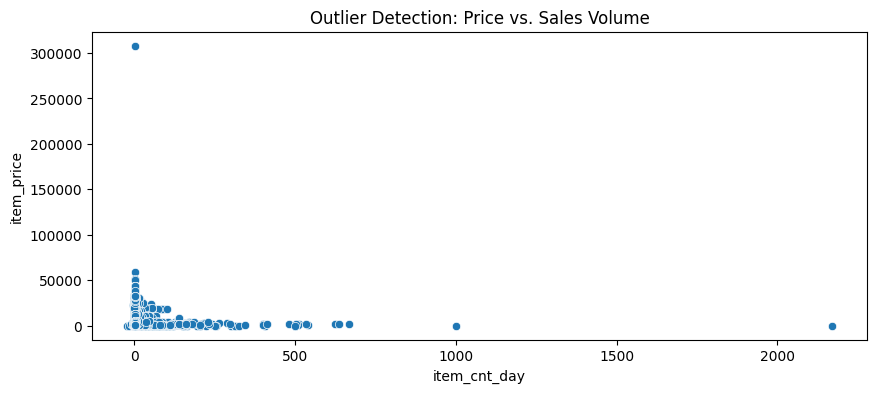

In [ ]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x=df_final['item_cnt_day'], y=df_final['item_price'])
plt.title('Outlier Detection: Price vs. Sales Volume')
plt.show()

На графике видно несколько записей которые сильно выделяются по числу продаж или по цене.

In [ ]:
df_final.nlargest(10, "item_price").head(10)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,week_day,item_name,item_category_id,item_category_name,shop_name,city
1163157,2013-12-13,11,12,6066,307980.0,1.0,2013,12,13,4,Radmin 3 - 522 лиц.,75,Программы - Для дома и офиса,Интернет-магазин ЧС,Интернет-магазин
885137,2013-09-17,8,12,11365,59200.0,1.0,2013,9,17,1,Доставка (EMS),9,Доставка товара,Интернет-магазин ЧС,Интернет-магазин
1488133,2014-03-20,14,25,13199,50999.0,1.0,2014,3,20,3,Коллекционные шахматы (Властелин Колец),69,Подарки - Сувениры,"Москва ТРК ""Атриум""",Москва
2327153,2015-01-29,24,12,7241,49782.0,1.0,2015,1,29,3,UserGate Proxy & Firewall 6.X с модулем фильтр...,75,Программы - Для дома и офиса,Интернет-магазин ЧС,Интернет-магазин
2885686,2015-10-23,33,42,13403,42990.0,1.0,2015,10,23,4,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,Игровые консоли - XBOX ONE,"СПб ТК ""Невский Центр""",СПб
2910150,2015-10-29,33,12,13403,42990.0,1.0,2015,10,29,3,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,Игровые консоли - XBOX ONE,Интернет-магазин ЧС,Интернет-магазин
2917754,2015-10-20,33,3,13403,42990.0,1.0,2015,10,20,1,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,Игровые консоли - XBOX ONE,"Балашиха ТРК ""Октябрь-Киномир""",Балашиха
2931374,2015-10-20,33,22,13403,42990.0,1.0,2015,10,20,1,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,Игровые консоли - XBOX ONE,Москва Магазин С21,Москва
1006637,2013-10-24,9,12,7238,42000.0,1.0,2013,10,24,3,UserGate Proxy & Firewall 6.X до 100 сессий,75,Программы - Для дома и офиса,Интернет-магазин ЧС,Интернет-магазин
2893094,2015-10-20,33,38,13403,41990.0,1.0,2015,10,20,1,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,Игровые консоли - XBOX ONE,"Омск ТЦ ""Мега""",Омск


In [25]:
df_final.drop(1163158, inplace=True)

Уникальный случай что кто-то купил лицензию на программу ровно на 522 человека, такое вряд-ли повторится, поэтому лучше всего удалить эту запись.

Цены во всех других больших записях выглядят оправдано кроме записи с доставкой.

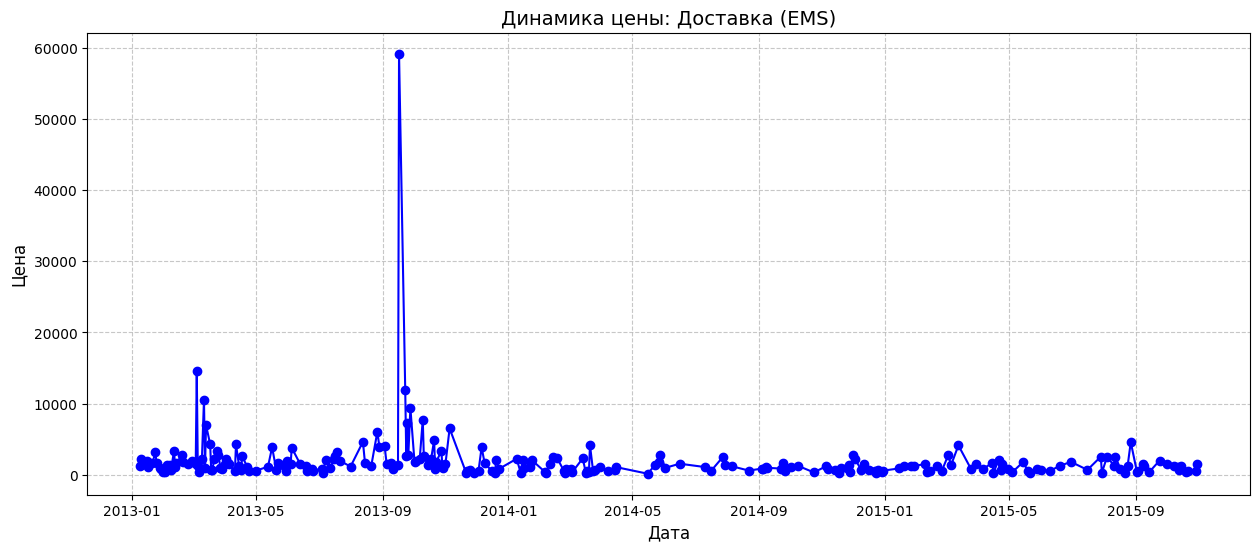

In [ ]:
EMS_data = df_final[df_final["item_name"] == "Доставка (EMS)"].copy()
EMS_data['date'] = pd.to_datetime(EMS_data['date'], format='%d.%m.%Y')
daily_sales = EMS_data.groupby('date')['item_price'].sum()
plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', color='b')
plt.title('Динамика цены: Доставка (EMS)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [ ]:
indices_to_drop = df_final[df_final["item_name"] == "Доставка (EMS)"].nlargest(1, "item_price").index
df_final = df_final.drop(indices_to_drop)

Тут 1 точка слишком сильно выделяется от всех других записей которых довольно много, поэтому её стоит убрать.

In [28]:
top_10_cnt = df_final.nlargest(10, "item_cnt_day")
top_10_cnt.head(10)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,week_day,item_name,item_category_id,item_category_name,shop_name,city
2909812,2015-10-28,33,12,11373,0.908714,2169.0,2015,10,28,2,Доставка до пункта выдачи (Boxberry),9,Доставка товара,Интернет-магазин ЧС,Интернет-магазин
2326924,2015-01-15,24,12,20949,4.000000,1000.0,2015,1,15,3,Фирменный пакет майка 1С Интерес белый (34*42)...,71,"Подарки - Сумки, Альбомы, Коврики д/мыши",Интернет-магазин ЧС,Интернет-магазин
2864229,2015-09-30,32,12,9248,1692.526158,669.0,2015,9,30,2,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС,Интернет-магазин
2851085,2015-09-30,32,55,9249,1702.825746,637.0,2015,9,30,2,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн,Цифровой
2608034,2015-04-14,27,12,3731,1904.548077,624.0,2015,4,14,1,"Grand Theft Auto V [PC, русские субтитры]",30,Игры PC - Стандартные издания,Интернет-магазин ЧС,Интернет-магазин
2626175,2015-05-19,28,12,11373,155.192950,539.0,2015,5,19,1,Доставка до пункта выдачи (Boxberry),9,Доставка товара,Интернет-магазин ЧС,Интернет-магазин
2851067,2015-09-29,32,55,9249,1500.000000,533.0,2015,9,29,1,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн,Цифровой
2048513,2014-10-02,21,12,9242,1500.000000,512.0,2014,10,2,3,"Билет ""ИгроМир 2014"" (на один день (отдельно -...",8,Билеты (Цифра),Интернет-магазин ЧС,Интернет-магазин
2067664,2014-10-09,21,55,19437,899.000000,508.0,2014,10,9,3,"Средиземье: Тени Мордора [PC, Цифровая версия]",31,Игры PC - Цифра,Цифровой склад 1С-Онлайн,Цифровой
2864254,2015-09-29,32,12,9248,1500.000000,504.0,2015,9,29,1,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС,Интернет-магазин


Исследуем записи с большим числом продаж на правдоподобность при помощи скользящего MAD-score.

In [ ]:
def rolling_mad_score(df, target_date):
    start_date = target_date - pd.Timedelta(days=45)
    end_date = target_date + pd.Timedelta(days=45)
    mask = (df["date"] >= start_date) & (df["date"] <= end_date) & (df["date"] != target_date)
    target_val = df[df["date"] == target_date]['item_cnt_day'].iloc[0]
    window_data = df.loc[mask, 'item_cnt_day']
    if window_data.sum() == 0:
        return -1
    median = np.median(window_data)
    mad = np.median(np.abs(window_data - median))
    score = np.abs(target_val - median) / (mad + 1e-6)
    return score

for index, row in top_10_cnt.iterrows():
    vals = df_final[df_final["item_name"] == row["item_name"]].copy()
    print(index, "   ", row["item_name"], "   ", row["item_cnt_day"], "   ",rolling_mad_score(vals, row["date"]))

2909812     Доставка до пункта выдачи (Boxberry)     2169.0     1082.4994587502706
2326924     Фирменный пакет майка 1С Интерес белый (34*42) 45 мкм     1000.0     0.99999950000025
2864229     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) [Цифровая версия]     669.0     132.5999734800053
2851085     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) УПР [Цифровая версия]     637.0     125.99997480000503
2608034     Grand Theft Auto V [PC, русские субтитры]     624.0     18.33332722222426
2626175     Доставка до пункта выдачи (Boxberry)     539.0     88.49998525000245
2851067     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) УПР [Цифровая версия]     533.0     105.1999789600042
2048513     Билет "ИгроМир 2014" (на один день (отдельно - 4, 5 октября 2014))     512.0     2.99999850000075
2067664     Средиземье: Тени Мордора [PC, Цифровая версия]     508.0     505.99949400050605
2864254     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) [Цифровая версия]     504.0     99.59998008000399


Анализ при помощи скользящего MAD-score показал, что все записи кроме двух имеют экстримально большое значение означающее выброс.

In [30]:
df_final.drop([2909818, 2864235, 2851091, 2608040, 2626181, 2851073, 2067669, 2864260], inplace=True)

Ближе исследуем все доставки (Boxberry).

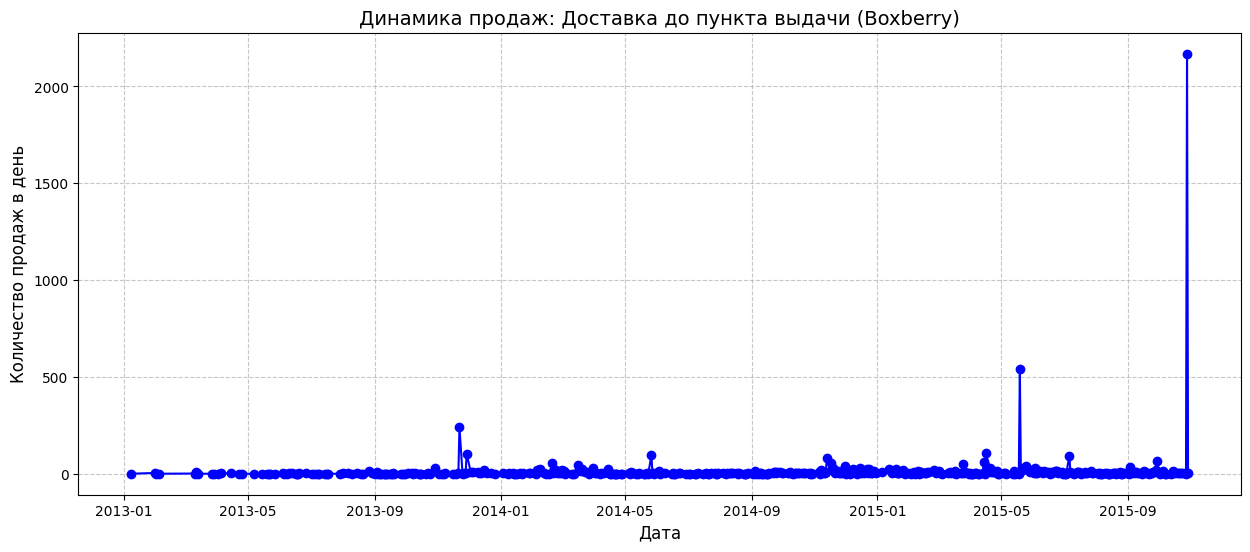

In [ ]:
boxberry_data = df_final[df_final["item_name"] == "Доставка до пункта выдачи (Boxberry)"].copy()
boxberry_data['date'] = pd.to_datetime(boxberry_data['date'], format='%d.%m.%Y')
daily_sales = boxberry_data.groupby('date')['item_cnt_day'].sum()
plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', color='b')
plt.title('Динамика продаж: Доставка до пункта выдачи (Boxberry)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество продаж в день', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [ ]:
indices_to_drop = df_final[df_final["item_name"] == "Доставка до пункта выдачи (Boxberry)"].nlargest(2, "item_cnt_day").index
df_final = df_final.drop(indices_to_drop)

Для службы доставки Boxberry были обнаружены две записи, которые значительно отличаются от общей структуры данных.

На фоне большого количества небольших значений эти точки выглядят аномально и могут ухудшать обучение модели.

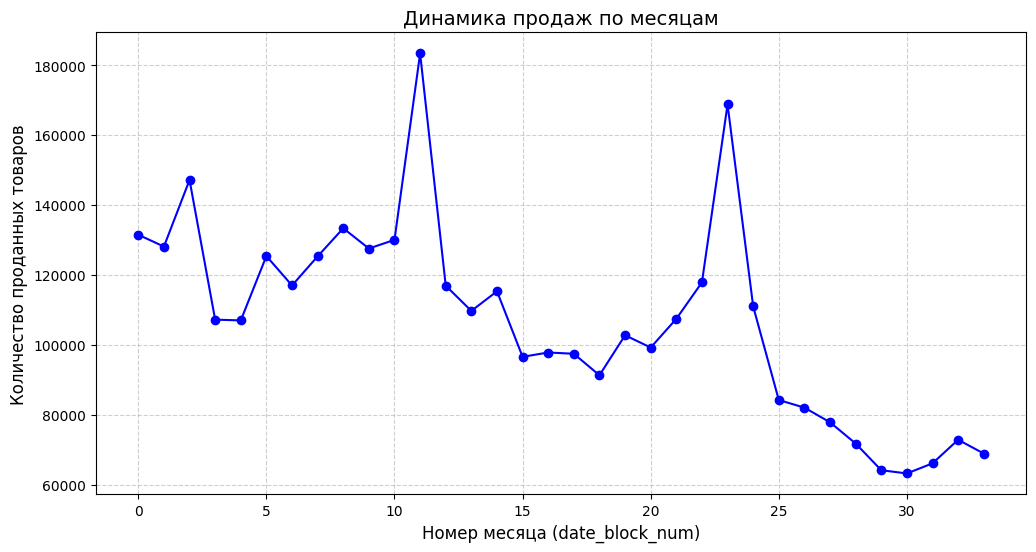

In [ ]:
monthly_sales = df_final.groupby("date_block_num")["item_cnt_day"].sum()
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linestyle='-')
plt.title('Динамика продаж по месяцам', fontsize=14)
plt.xlabel('Номер месяца (date_block_num)', fontsize=12)
plt.ylabel('Количество проданных товаров', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

На графике месячных продаж хорошо заметна сезонность.

Наибольший рост наблюдается в декабре, что связано с:

- новогодними праздниками;
- сезонными акциями.

А так же что в целом динамика продаж падает со временем, это может быть связано как с тем, что некоторые магазины начали отказываться от данного ПО, так и с тем, что большая часть продукции в датасете это электронные товары, и люди активно переходят в интернет, следовательно отпадает нужда покупать физические товары в магазинах.

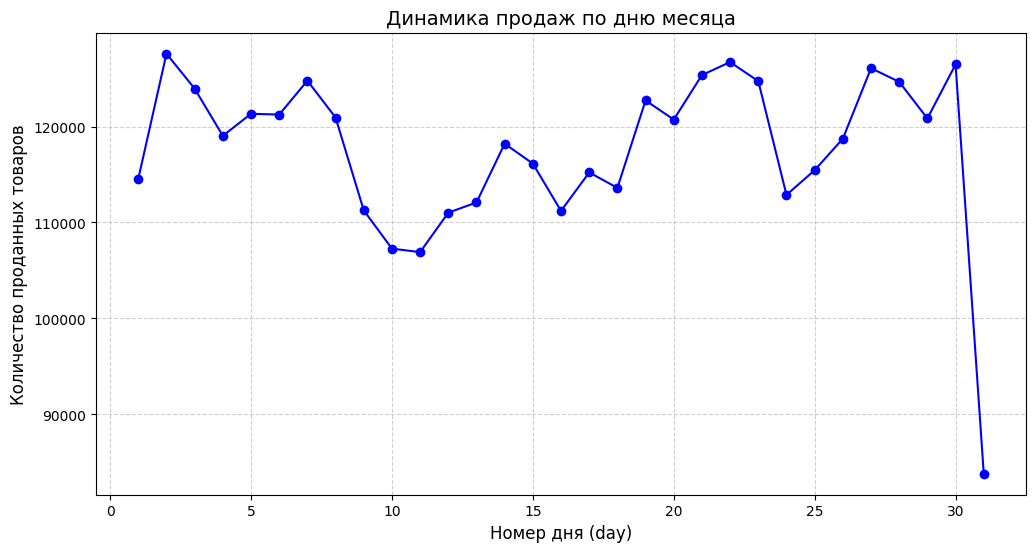

In [ ]:
monthly_sales = df_final.groupby("day")["item_cnt_day"].sum()
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linestyle='-')
plt.title('Динамика продаж по дню месяца', fontsize=14)
plt.xlabel('Номер дня (day)', fontsize=12)
plt.ylabel('Количество проданных товаров', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

В течение месяца наблюдаются определённые закономерности.

Продажи снижаются примерно в середине месяца, а в последние дни количество записей меньше из-за особенностей сбора данных.

Это указывает на наличие внутримесячной сезонности.

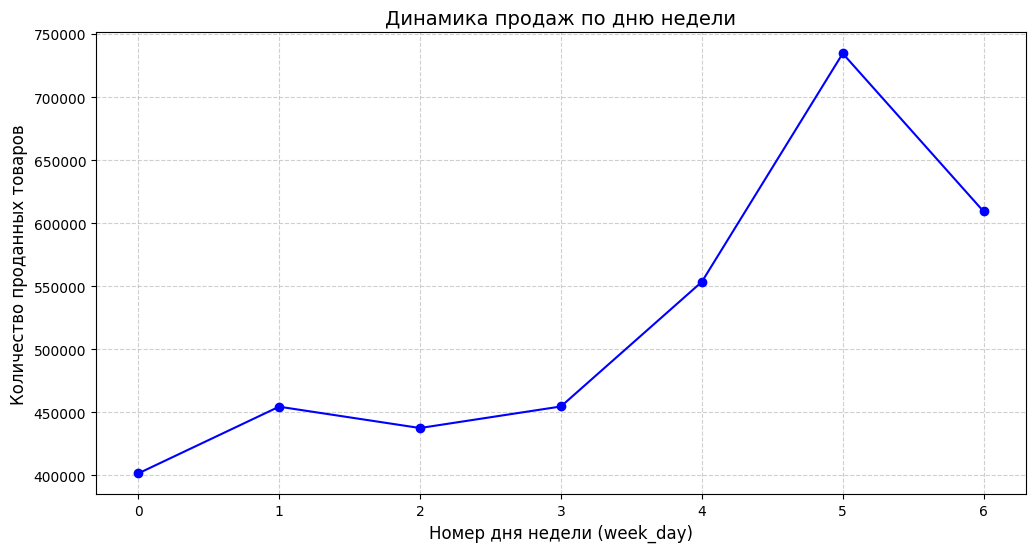

In [ ]:
monthly_sales = df_final.groupby("week_day")["item_cnt_day"].sum()
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linestyle='-')
plt.title('Динамика продаж по дню недели', fontsize=14)
plt.xlabel('Номер дня недели (week_day)', fontsize=12)
plt.ylabel('Количество проданных товаров', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

На графике видно что люди больше покупают на выходных, а больше всего в субботу, и что в течении недели происходит рост числа продаж.

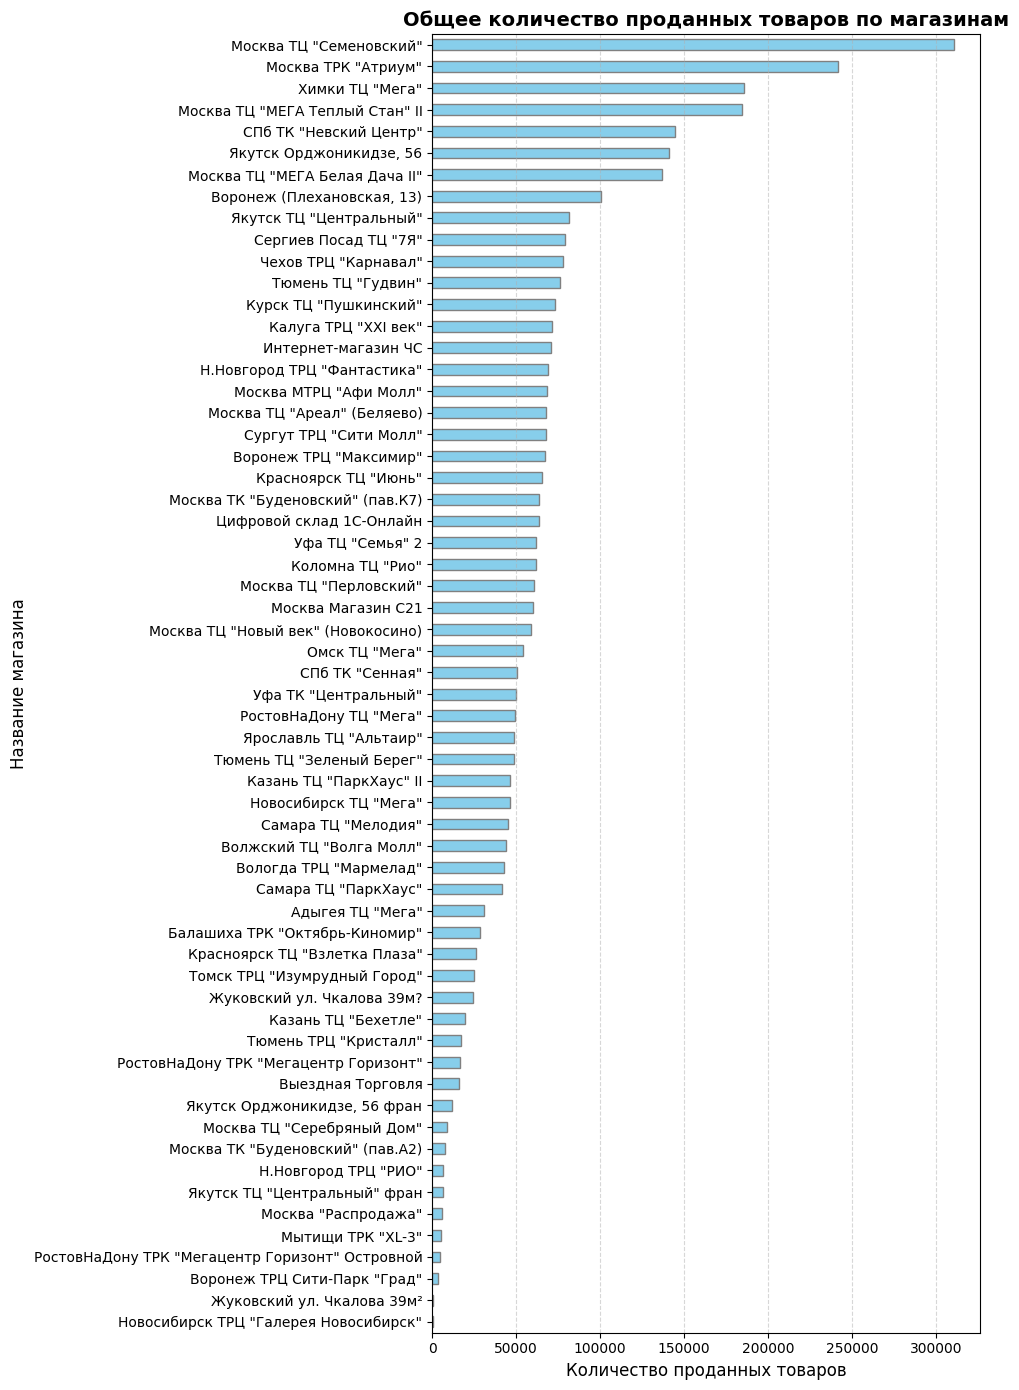

In [ ]:
shop_sales = df_final.groupby("shop_name")["item_cnt_day"].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 14))
shop_sales.plot(kind='barh', color='skyblue', edgecolor='gray')
plt.title('Общее количество проданных товаров по магазинам', fontsize=14, fontweight='bold')
plt.xlabel('Количество проданных товаров', fontsize=12)
plt.ylabel('Название магазина', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Продажи распределены между магазинами крайне неравномерно.

Некоторые магазины продают в несколько раз больше товаров, чем остальные.
Это может быть связано с:

- размером магазина;
- расположением;
- популярностью;
- размером города.

Следовательно, признаки магазина имеют высокую важность.

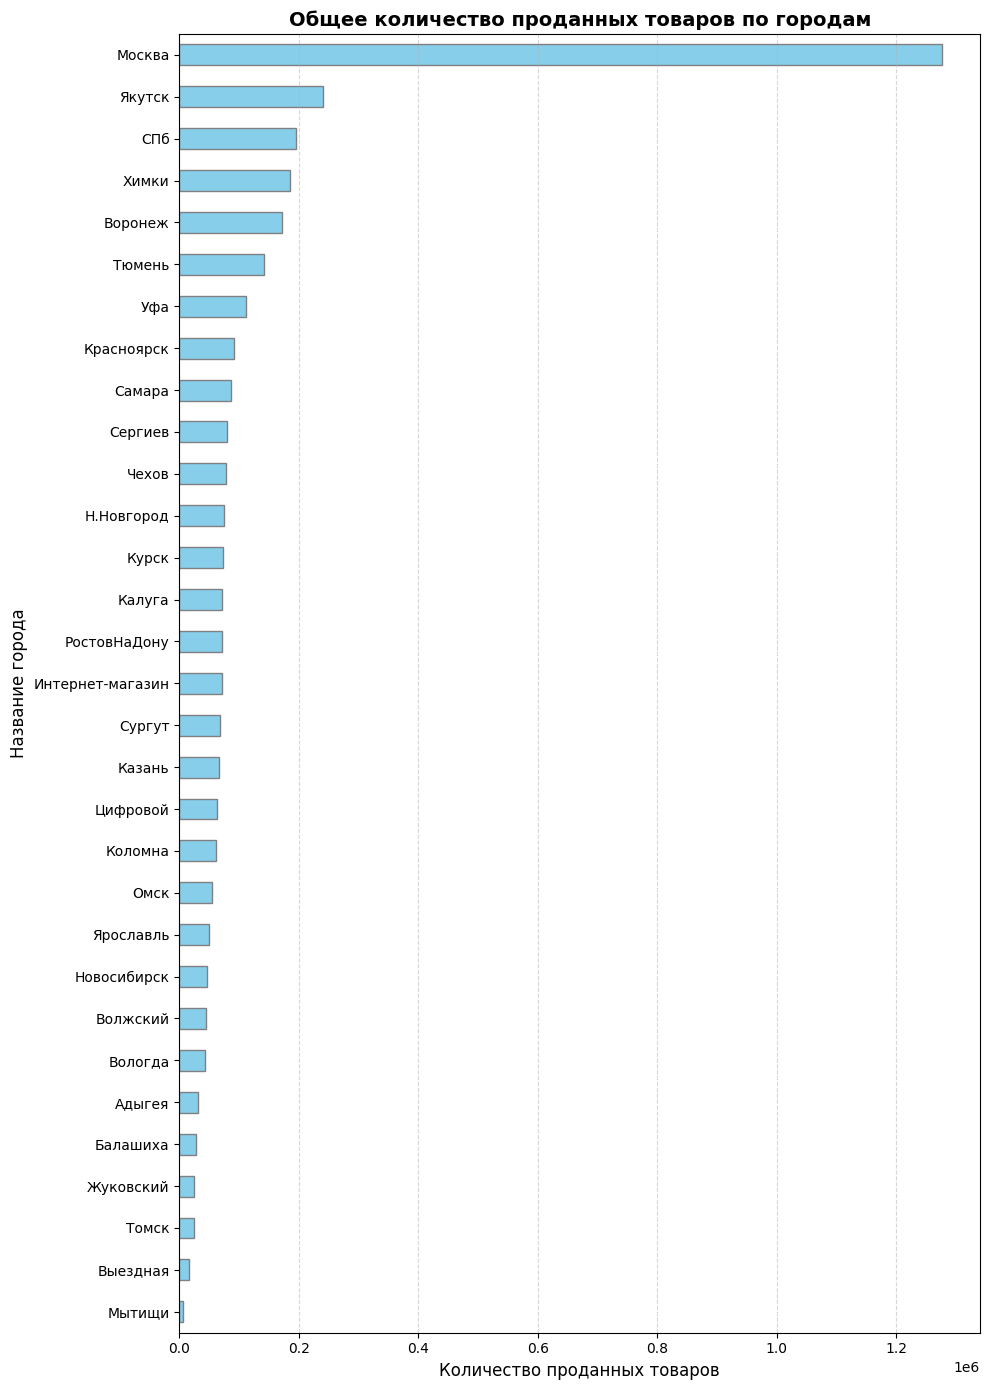

In [ ]:
shop_sales = df_final.groupby("city")["item_cnt_day"].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 14))
shop_sales.plot(kind='barh', color='skyblue', edgecolor='gray')
plt.title('Общее количество проданных товаров по городам', fontsize=14, fontweight='bold')
plt.xlabel('Количество проданных товаров', fontsize=12)
plt.ylabel('Название города', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Как и ожидалось, крупнейшие города демонстрируют значительно больший объём продаж.

Это означает, что географическая информация может быть полезной как признак для задачи.

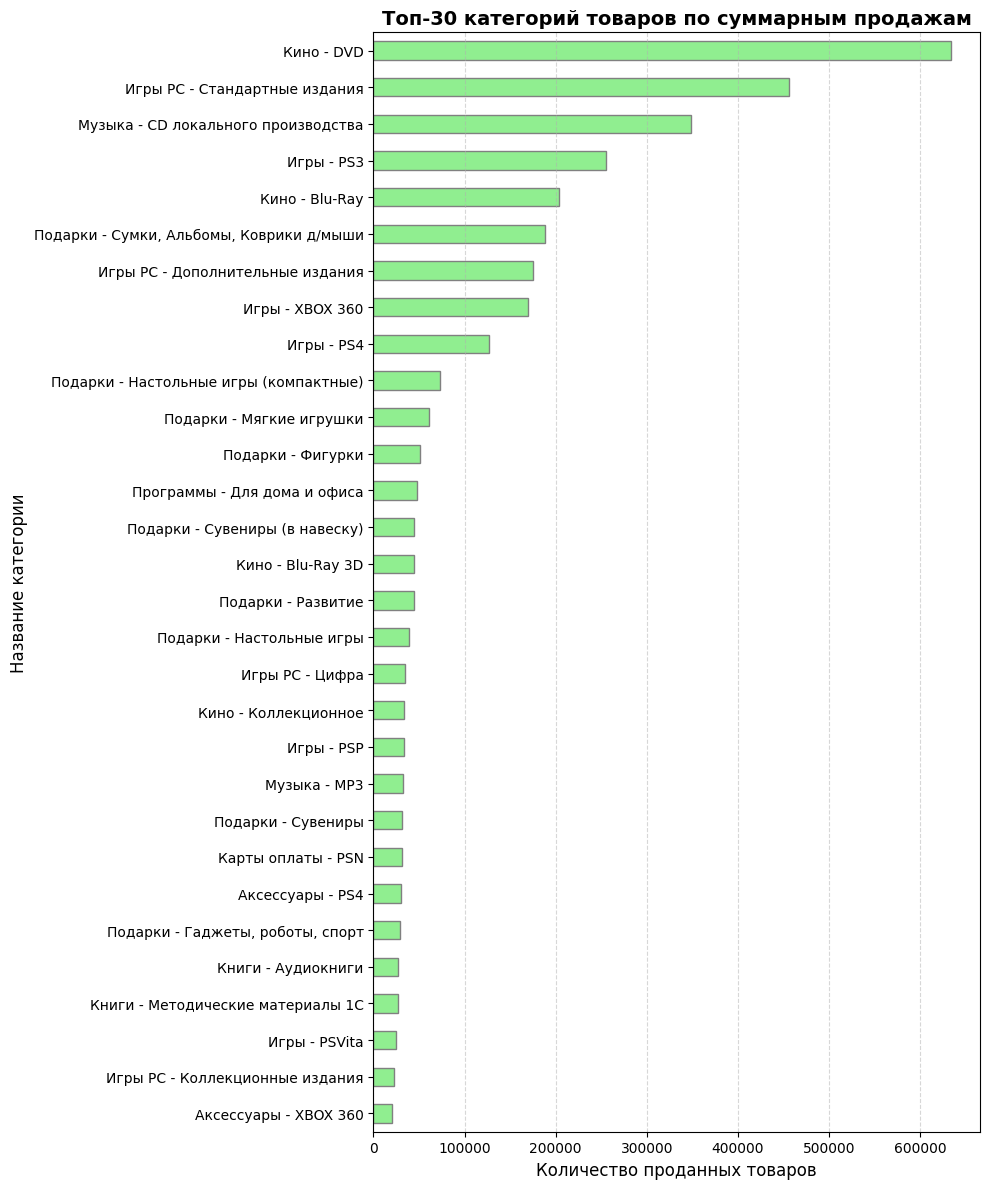

In [ ]:
top_categories = df_final.groupby("item_category_name")["item_cnt_day"].sum().sort_values(ascending=True).tail(30)
plt.figure(figsize=(10, 12))
top_categories.plot(kind='barh', color='lightgreen', edgecolor='gray')
plt.title('Топ-30 категорий товаров по суммарным продажам', fontsize=14, fontweight='bold')
plt.xlabel('Количество проданных товаров', fontsize=12)
plt.ylabel('Название категории', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Наиболее популярными категориями являются товары, связанные с электроникой и игровыми продуктами.

Категория товара оказывает сильное влияние на объём продаж и обязательно должна использоваться как признак модели.

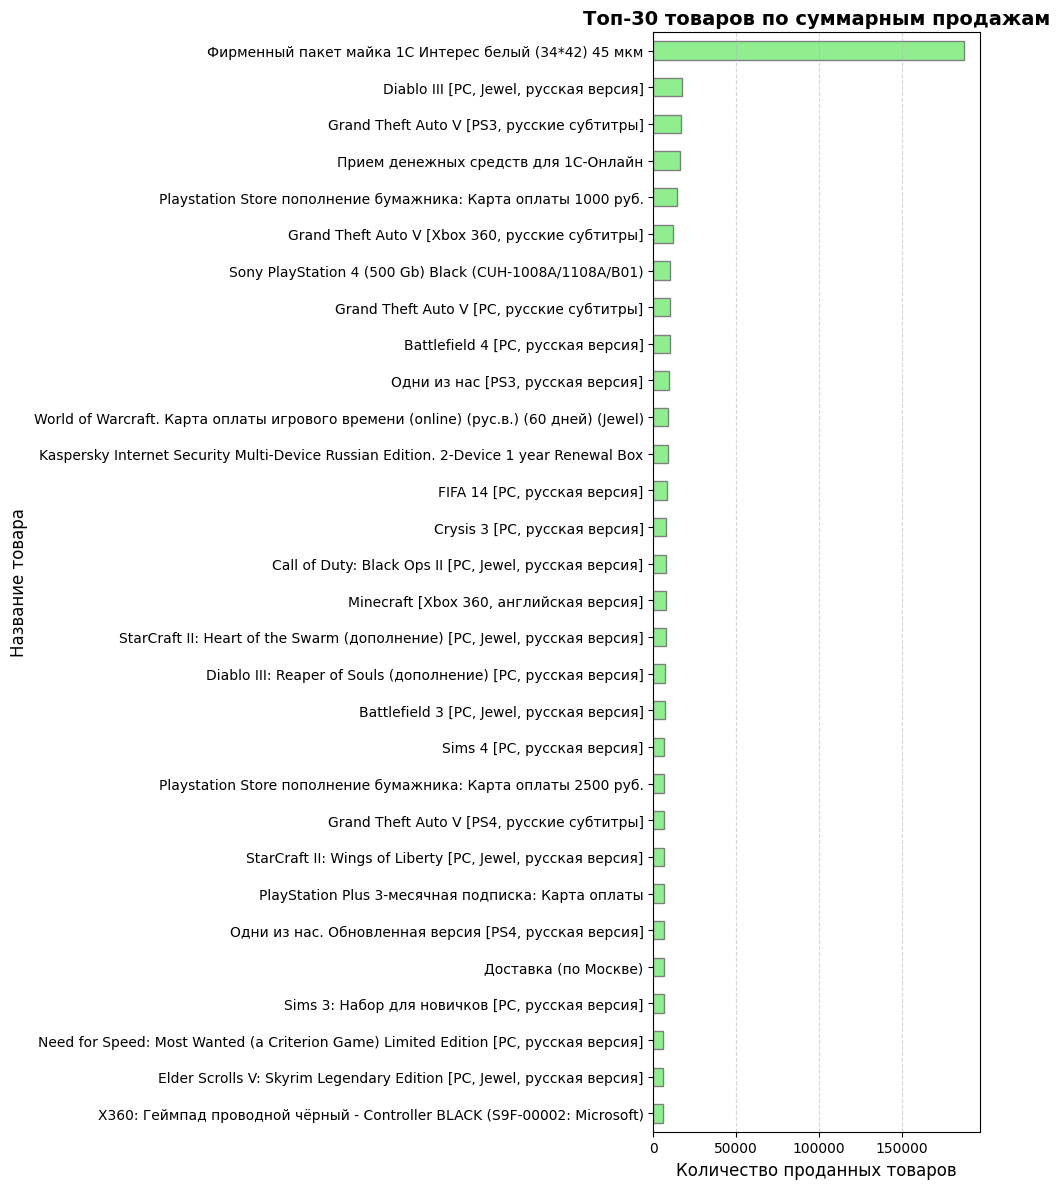

In [ ]:
top_items = df_final.groupby("item_name")["item_cnt_day"].sum().sort_values(ascending=True).tail(30)
plt.figure(figsize=(10, 12))
top_items.plot(kind='barh', color='lightgreen', edgecolor='gray')
plt.title('Топ-30 товаров по суммарным продажам', fontsize=14, fontweight='bold')
plt.xlabel('Количество проданных товаров', fontsize=12)
plt.ylabel('Название товара', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Наиболее продаваемые товары включают различные пакеты.

Вероятно, часть таких товаров регулярно продаётся вместе с другими продуктами.

Большая часть остальных товаров - игры и программы

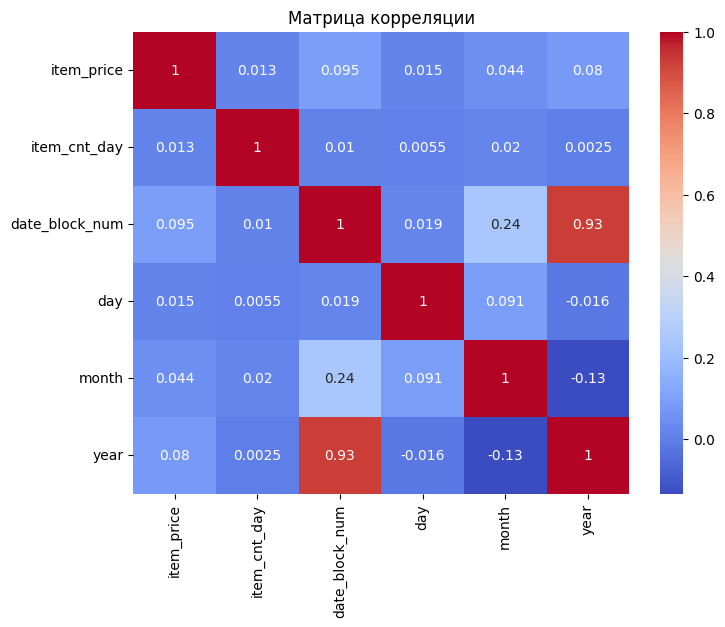

In [44]:
numeric_cols = ['item_price', 'item_cnt_day', 'date_block_num','day', 'month', 'year']
corr = df_final[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции')

plt.show()

Признаки, кроме связанных с датой, очень слабо скорелированы

In [41]:
unique_pairs = train[['shop_id', 'item_id']].drop_duplicates().shape[0]
all_possible = train['shop_id'].nunique() * train['item_id'].nunique()

print('Имеется пар:', unique_pairs)
print('Возможных пар:', all_possible)
print('Отношение созданных к возможным:', unique_pairs / all_possible)

Имеется пар: 424124
Возможных пар: 1308420
Отношение созданных к возможным: 0.32414973785176016


В датасете используется только около одной трети всех возможных комбинаций `shop_id` и `item_id`.

Это означает, что:

- многие товары никогда не продавались в определённых магазинах;
- данные являются сильно разреженными;
- задача прогнозирования становится существенно сложнее.

Модель будет будет часто встречаться с незнакомыми комбинациями товаров и магазинов, что будет ухудшать качество прогнозов.

In [42]:
import pandas as pd
df_grouped = df_final.groupby(['date_block_num', 'shop_id', 'item_id'])['item_cnt_day'].sum().reset_index()
df_grouped = df_grouped.sort_values(['shop_id', 'item_id', 'date_block_num'])
df_grouped['lag_1'] = df_grouped.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(1)
df_grouped['lag_3'] = df_grouped.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(3)
lag_cols = ['lag_1', 'lag_3']
df_grouped[lag_cols] = df_grouped[lag_cols].fillna(0)

df_grouped.head()

,date_block_num,shop_id,item_id,item_cnt_day,lag_1,lag_3
63224,1,0,30,31.0,0.0,0.0
63225,1,0,31,11.0,0.0,0.0
0,0,0,32,6.0,0.0,0.0
63226,1,0,32,10.0,6.0,0.0
1,0,0,33,3.0,0.0,0.0


In [43]:
df_final = df_final.merge(
    df_grouped[['date_block_num', 'shop_id', 'item_id', 'lag_1', 'lag_3']], 
    on=['date_block_num', 'shop_id', 'item_id'], 
    how='left'
)
df_final.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,week_day,item_name,item_category_id,item_category_name,shop_name,city,lag_1,lag_3
0,2013-01-02,0,59,22154,999.00,1.0,2013,1,2,2,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",Ярославль,0.0,0.0
1,2013-01-03,0,25,2552,899.00,1.0,2013,1,3,3,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",Москва,0.0,0.0
2,2013-01-05,0,25,2552,899.00,-1.0,2013,1,5,5,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",Москва,0.0,0.0
3,2013-01-06,0,25,2554,1709.05,1.0,2013,1,6,6,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",Москва,0.0,0.0
4,2013-01-15,0,25,2555,1099.00,1.0,2013,1,15,1,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",Москва,0.0,0.0


Были добавлены признаки продаж за предыдущий месяц и за предыдущие три месяца.

Лаговые признаки являются одними из самых важных для временных рядов, поскольку позволяют модели учитывать:

- тренды;
- сезонность;
- инерцию продаж;
- популярность товара в прошлом.

Но есть проблема с записями в начале таблицы когда нету данных про прошлое, а так же с продуктами которые появились в каком-то магазине после января 2013, когда начались собираться данные в датасете.

## С чем я работаю?

Я работаю с временным рядом продаж товаров в различных магазинах, использующих программу от 1С для учета продаж.

Данные содержат:

- информацию о продажах;
- товары и категории;
- магазины;
- временные признаки.

Основная задача — предсказать количество продаж товаров в будущих месяцах.

## Какие основные закономерности присутствуют в данных?

В данных наблюдаются:

- сильная сезонность;
- рост продаж в декабре;
- общий спад числа продаж со временем;
- зависимость от дня недели;
- сильная разница между магазинами;
- сильная разница между категориями товаров;
- высокая разреженность комбинаций товаров и магазинов.

## Как взаимодействуют сущности данных?

Продажи зависят одновременно от:

- магазина;
- товара;
- категории;
- года;
- месяца;
- дня недели;
- дня месяца;
- города.

Один и тот же товар может продаваться по-разному в разных магазинах, а так же может продаваться по-разному в одном и том же магазине в разные даты.


## Что нужно сделать для получения хороших признаков?

- создать лаговые признаки;
- учитывать сезонность;
- добавить признаки города и больше признаков, связанных с датой;
- обработать выбросы;
- удалить или исправить ошибки данных.

## Какие проблемы возникают при прогнозировании?

Основные сложности:

- большое количество выбросов;
- редкие продажи;
- разреженность данных;
- новые товары и магазины;
- сильная сезонность.


Эти проблемы делают задачу прогнозирования достаточно сложной.

## Как можно делать прогнозы вручную?

Простейший способ ручного прогнозирования — использовать продажи предыдущих месяцев.

Например:

- брать предсказание из прошлого месяца
- брать сумма предсказаний за прошлые месяцы с различными коэфицентами
- брать средние продажи товара за прошлые месяцы в других городах, если в этом городе раньше не было этого товара

Прошлые значения продаж являются главным источником информации для прогнозирования.